In [1]:
import h3  # H3地理网格系统库，用于处理六边形网格化地理数据
import geopandas  # 地理数据处理库，基于pandas扩展，支持空间数据操作
import geodatasets  # 提供示例地理数据集
import contextily as cx  # 底图工具，用于添加网络地图背景
import matplotlib.pyplot as plt  # 绘图库，用于数据可视化

from utils import *

<LatLngPoly: [4/(3, 5)]>


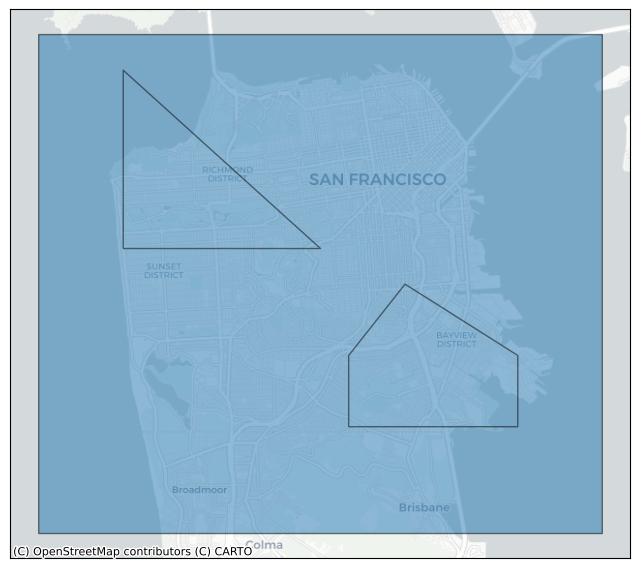

In [2]:
outer = [
    (37.804, -122.412),
    (37.778, -122.507),
    (37.733, -122.501)
]

outer2 = [
    [(37.68, -122.54), (37.68, -122.34), (37.82, -122.34), (37.82, -122.54)],
    [(37.76, -122.51), (37.76, -122.44), (37.81, -122.51)],
]

outer3 = [
    [(37.68, -122.54), (37.68, -122.34), (37.82, -122.34), (37.82, -122.54)],
    [(37.76, -122.51), (37.76, -122.44), (37.81, -122.51)],
    [(37.71, -122.43), (37.71, -122.37), (37.73, -122.37), (37.75, -122.41),(37.73, -122.43)],
]


poly = h3.LatLngPoly(*outer3)
print(poly)
plot_shape(poly)

<LatLngPoly: [3/(3,)]>


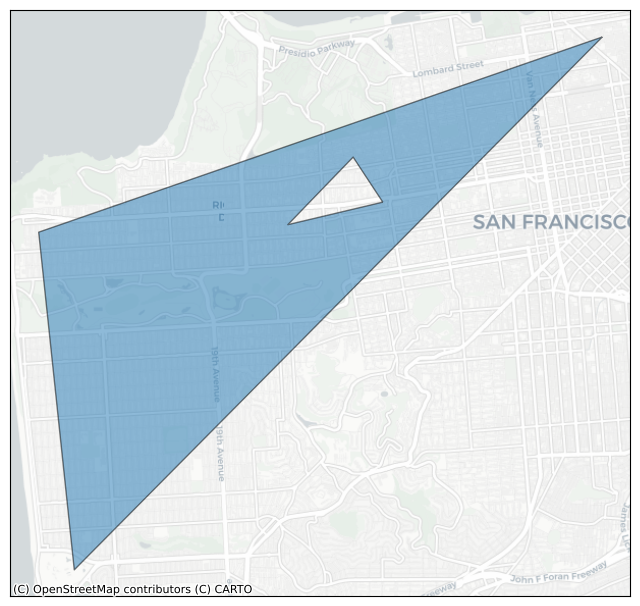

In [3]:
hole1 = [
    (37.782, -122.449),
    (37.779, -122.465),
    (37.788, -122.454),
]

poly = h3.LatLngPoly(outer, hole1)
print(poly)
plot_shape(poly)

<LatLngPoly: [3/(3, 4)]>


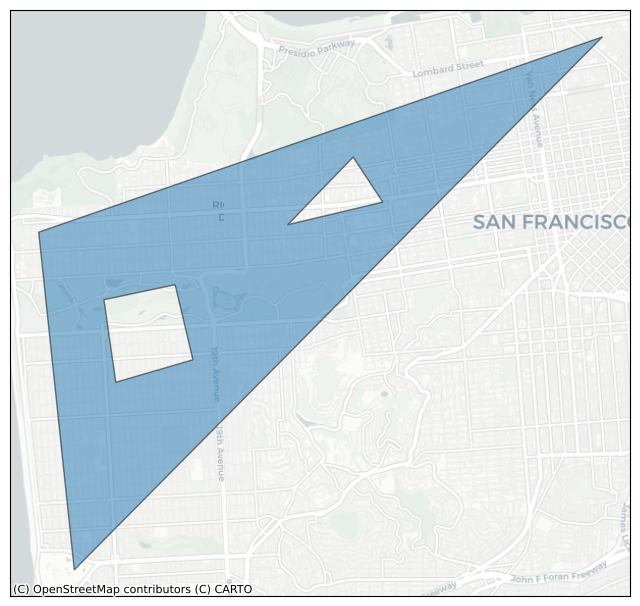

In [4]:
hole2 = [
    (37.771, -122.484),
    (37.761, -122.481),
    (37.758, -122.494),
    (37.769, -122.496),
]

poly = h3.LatLngPoly(outer, hole1, hole2)
print(poly)
plot_shape(poly)

In [5]:
poly = h3.LatLngPoly(outer, hole1, hole2)
poly

<LatLngPoly: [3/(3, 4)]>

In [6]:
poly.outer, poly.holes

(((37.804, -122.412), (37.778, -122.507), (37.733, -122.501)),
 ([(37.782, -122.449), (37.779, -122.465), (37.788, -122.454)],
  [(37.771, -122.484),
   (37.761, -122.481),
   (37.758, -122.494),
   (37.769, -122.496)]))

In [7]:
d = poly.__geo_interface__
d

{'type': 'Polygon',
 'coordinates': (((-122.412, 37.804),
   (-122.507, 37.778),
   (-122.501, 37.733),
   (-122.412, 37.804)),
  ((-122.449, 37.782),
   (-122.465, 37.779),
   (-122.454, 37.788),
   (-122.449, 37.782)),
  ((-122.484, 37.771),
   (-122.481, 37.761),
   (-122.494, 37.758),
   (-122.496, 37.769),
   (-122.484, 37.771)))}

In [8]:
h3.geo_to_h3shape(d)

<LatLngPoly: [3/(3, 4)]>

In [9]:
poly.__geo_interface__ == h3.h3shape_to_geo(poly)

True

In [10]:
h3.h3shape_to_cells(poly, res=7)

['872830958ffffff', '87283095bffffff', '87283095affffff', '872830829ffffff']

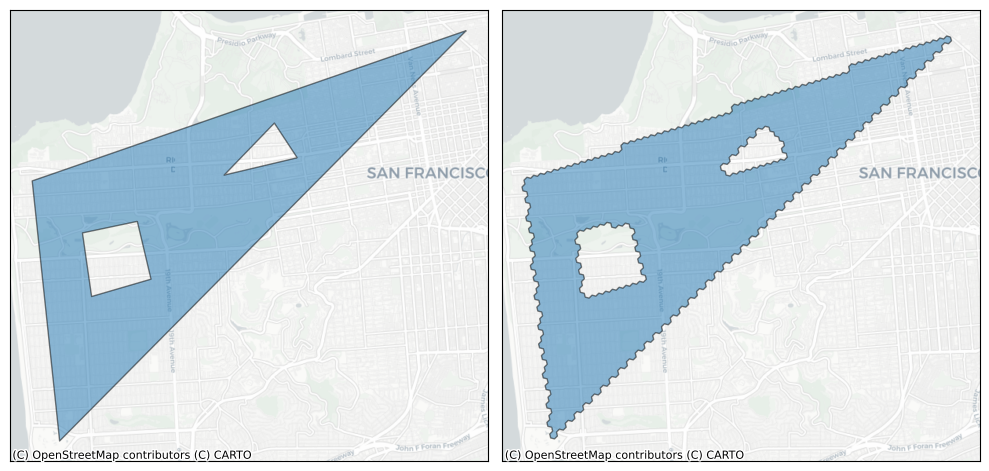

In [11]:
plot_shape_and_cells(poly, 10)

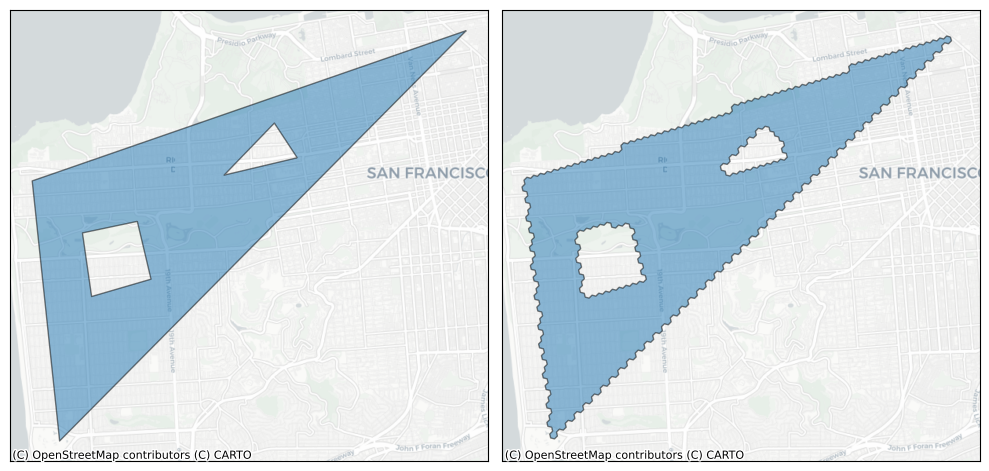

In [12]:
# Respects right-hand rule
poly = h3.LatLngPoly(outer, hole1, hole2)
plot_shape_and_cells(poly, res=10)

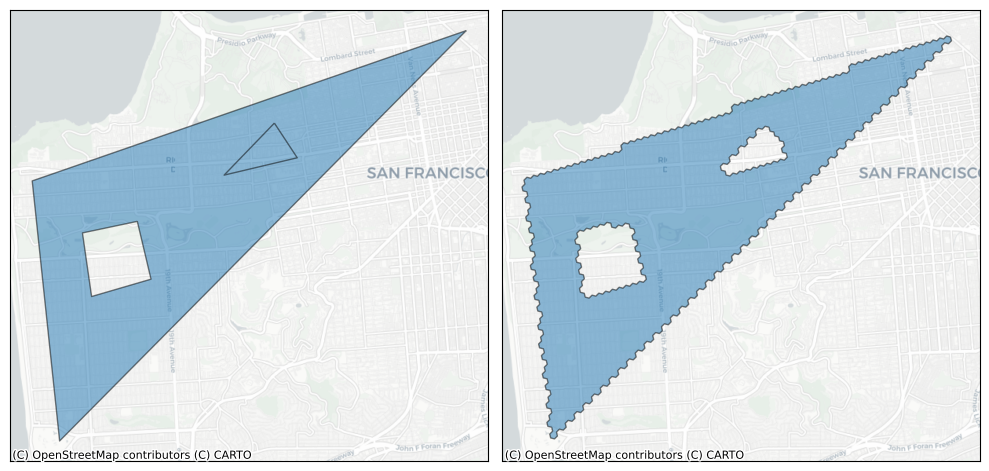

In [13]:
# Does not respect right-hand-rule; second hole is reversed
# Conversion to cells still works, tho!
poly = h3.LatLngPoly(outer, hole1[::-1], hole2)
plot_shape_and_cells(poly, res=10)